In [1]:
import os 
from collections import Counter , OrderedDict
from tqdm import tqdm 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report , auc , roc_auc_score , roc_curve 


import torch 
import torch.nn as nn 
from torch.optim import Adam
from torch.utils.data import Dataset , DataLoader , Subset
import torchvision 
from torchvision.datasets import ImageFolder  
from torchvision import transforms , models 
from torchvision.models import DenseNet121_Weights , DenseNet169_Weights , DenseNet201_Weights , VGG16_Weights , ResNet50_Weights 
from torchinfo import summary

In [2]:
device = 'cuda' if torch.cuda.is_available() else "cpu" 
device

'cuda'

In [3]:
print(os.getcwd())

m:\Machine learning carrer\Projects\DeepLearningProjects\Brain Stroke Classification Tf\src


In [4]:
path , dir  ,files = next(os.walk('../data/Train/Stroke/'))
file_count = len(files)
print(f'Stroke:{file_count}')  
path , dir  ,files = next(os.walk('../data/Train/Normal/'))
file_count = len(files)
print(f'Normal:{file_count}')  


Stroke:950
Normal:1426


# Read Data and split it in train , test , val 

### make configrations 

In [5]:
image_size = (224 , 224) 
batch_size = 64 
seed = 1337 

### make transformations 

In [6]:
train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### read all train Data 

In [7]:
train_data = ImageFolder(root='../data/Train' , transform=train_transform) 
val_data = ImageFolder('../data/Train/' , transform=test_transform)

In [8]:
labels = train_data.targets
print(type(labels))

<class 'list'>


In [9]:
train_indices  ,val_indices = train_test_split(range(len(train_data)) , 
                                               test_size=0.2 , 
                                               random_state=seed , 
                                               stratify=labels) 

In [10]:
train_set = Subset(
    train_data , 
    train_indices
) 
val_set = Subset(val_data , val_indices)

In [11]:
train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

In [12]:
train_labels = [train_data.targets[i] for i in train_indices]
val_labels = [val_data.targets[i] for i in val_indices]

print("Train distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

Train distribution:
Counter({0: 1140, 1: 760})

Validation distribution:
Counter({0: 286, 1: 190})


#### Read Test Data 

In [13]:
test_data = ImageFolder(root='../data/Test/' , transform=test_transform) 
test_loader = DataLoader(test_data , batch_size=32 , shuffle=False)

In [14]:
X_train , y_train = next(iter(train_loader)) 
X_train.shape
print(type(y_train))

<class 'torch.Tensor'>


In [15]:
train_counts = Counter(train_labels)  
n_normal = train_counts[0]
n_stroke = train_counts[1]

pos_weight_value = n_normal / n_stroke
pos_weight = torch.tensor([pos_weight_value], device=device)

print(f"pos_weight = {pos_weight_value:.3f}") 

pos_weight = 1.500


# EDA

In [16]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Total Training Images     : {len(train_data)}")
print(f"Training Split Images     : {len(train_set)}")
print(f"Validation Split Images   : {len(val_set)}")
print(f"Total Test Images         : {len(test_data)}")

print("\nClasses:")
for class_idx, class_name in enumerate(train_data.classes):
    print(f"{class_idx}: {class_name}")

DATASET OVERVIEW
Total Training Images     : 2376
Training Split Images     : 1900
Validation Split Images   : 476
Total Test Images         : 250

Classes:
0: Normal
1: Stroke


In [17]:
class_names = train_data.classes

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_data.targets)

train_class_counts = [
    train_counts[i] for i in range(len(class_names))
]

val_class_counts = [
    val_counts[i] for i in range(len(class_names))
]

test_class_counts = [
    test_counts[i] for i in range(len(class_names))
]

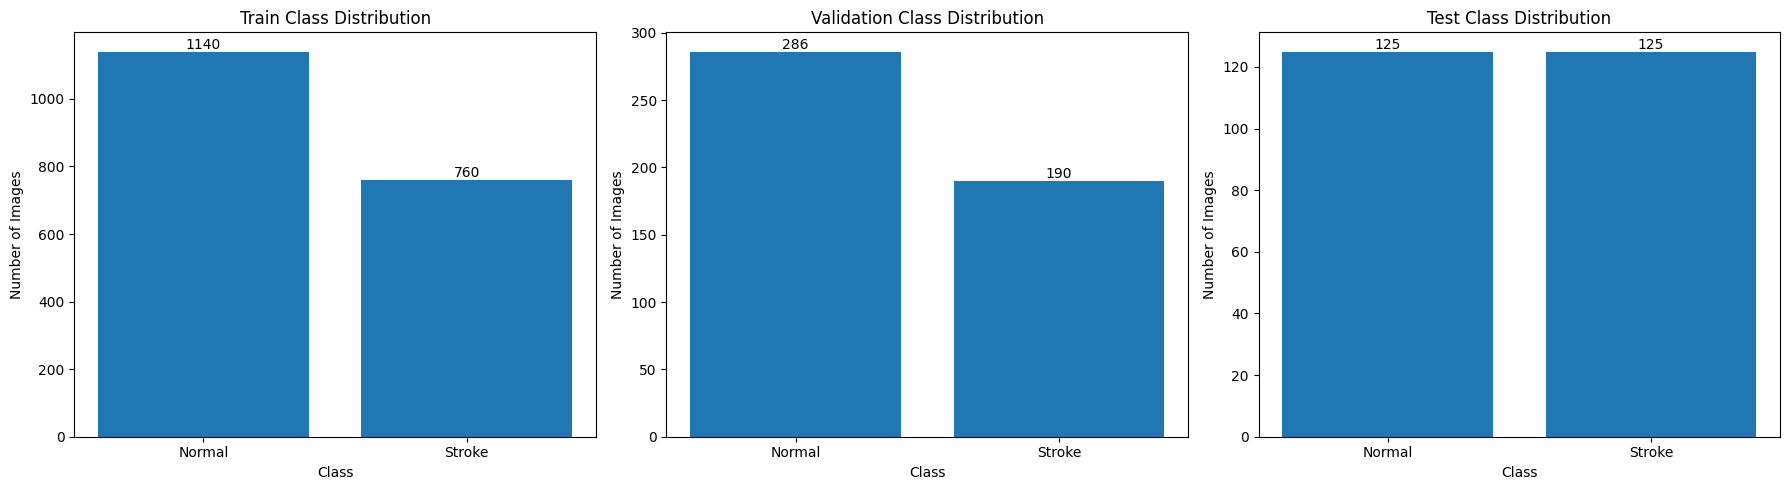

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = {
    "Train": train_class_counts,
    "Validation": val_class_counts,
    "Test": test_class_counts
}

for ax, (name, counts) in zip(axes, datasets.items()):

    bars = ax.bar(class_names, counts)

    ax.set_title(f"{name} Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Images")

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [19]:
def calculate_percentages(counts):
    total = sum(counts)
    return [(count / total) * 100 for count in counts]


train_percentages = calculate_percentages(train_class_counts)
val_percentages = calculate_percentages(val_class_counts)
test_percentages = calculate_percentages(test_class_counts)

distribution_df = pd.DataFrame({
    "Class": class_names,
    "Train": train_percentages,
    "Validation": val_percentages,
    "Test": test_percentages
})

distribution_df

,Class,Train,Validation,Test
0,Normal,60.0,60.084034,50.0
1,Stroke,40.0,39.915966,50.0


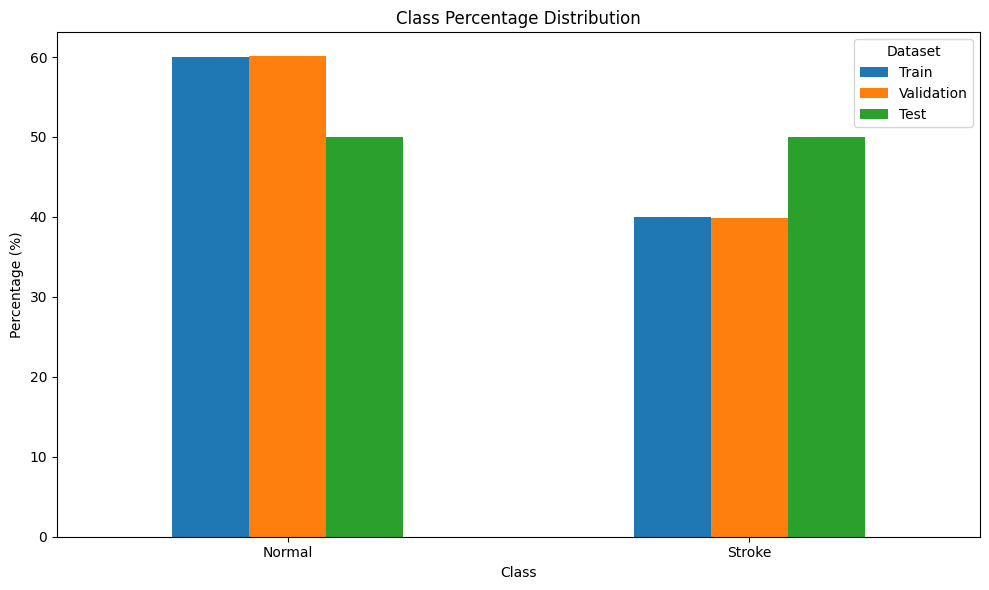

In [20]:
distribution_df.set_index("Class").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Class Percentage Distribution")
plt.xlabel("Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [21]:
visualization_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

visualization_data = ImageFolder(
    root="../data/Train",
    transform=visualization_transform
)

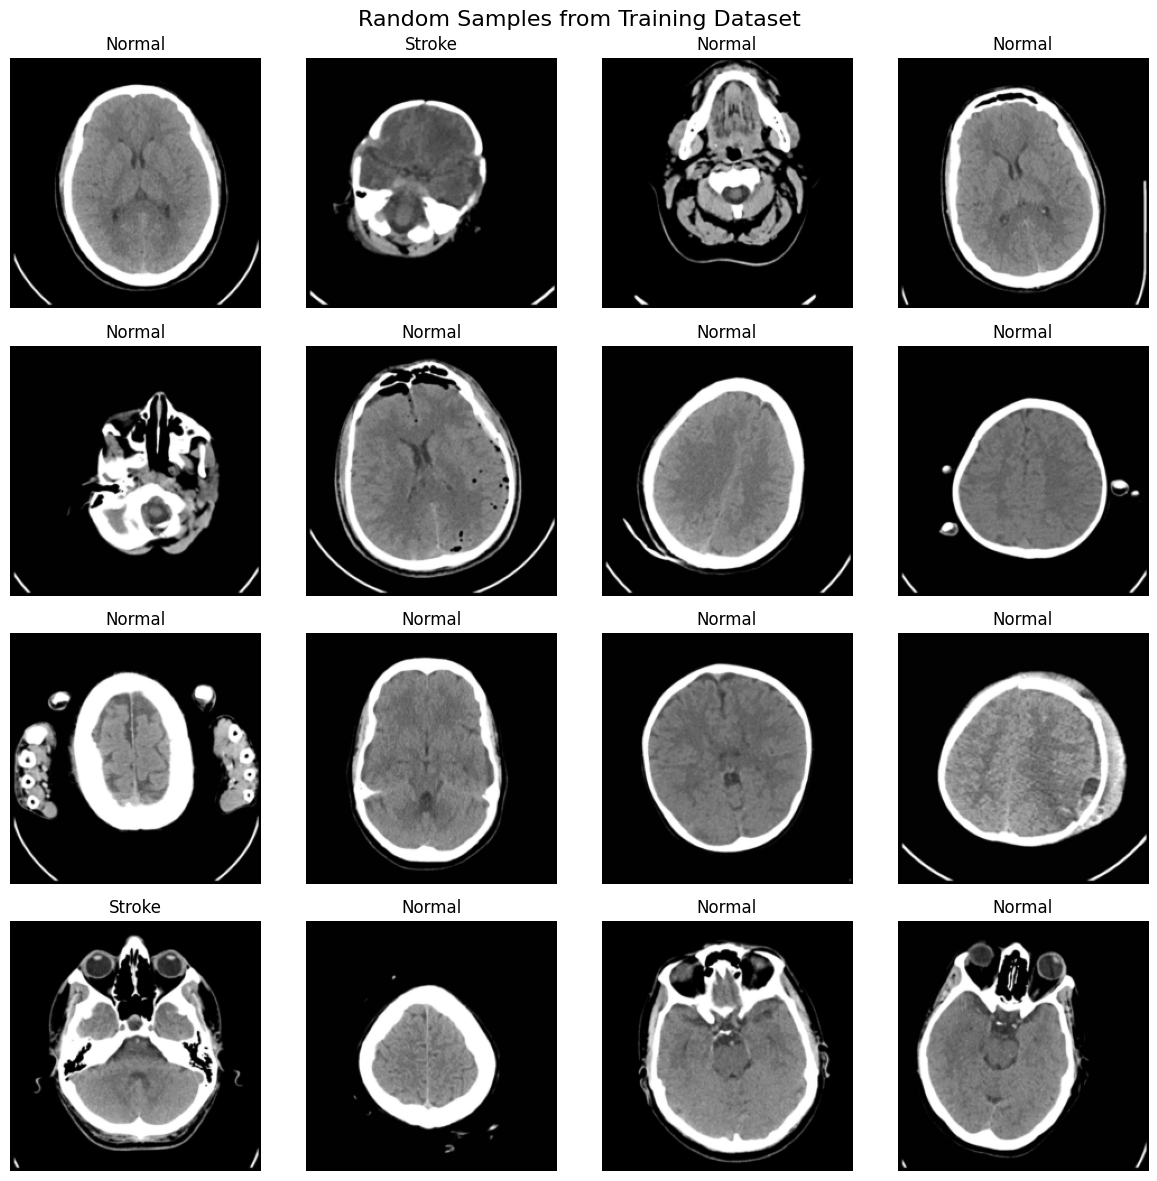

In [22]:
num_images = 16

random_indices = np.random.choice(
    len(visualization_data),
    size=num_images,
    replace=False
)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.flat, random_indices):

    image, label = visualization_data[idx]

    image = image.permute(1, 2, 0).numpy()

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle(
    "Random Samples from Training Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

# DenseNet model 

In [23]:
densenet_model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
densenet_model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [ ]:
for name, param in densenet_model.features.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in densenet_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in densenet_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 3,185,128 / 7,978,856


In [25]:
densenet_model.classifier

Linear(in_features=1024, out_features=1000, bias=True)

In [26]:
densenet_model.classifier = nn.Sequential(
    OrderedDict(
        [
            ('fc1'  , nn.Linear(in_features=1024 , out_features=256)) , 
            ('relu1' , nn.ReLU()) , 
            ('dropout1' , nn.Dropout(0.4)),
            ('fc2' , nn.Linear(256 , 64)) , 
            ('relu2' , nn.ReLU()) ,
            ('dropout2' , nn.Dropout(0.4)),
            ('fc3' , nn.Linear(64 , 1)) 
        ]
    )
)

In [27]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = Adam(
    densenet_model.classifier.parameters(),
    lr=5e-4,          
    betas=(0.9, 0.999),
    weight_decay=1e-4  
) 

In [28]:
densenet_model.to(device=device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

In [29]:
print(densenet_model.features.conv0)

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [30]:
print(densenet_model.classifier)

Sequential(
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


In [31]:
summary(
    densenet_model,
    input_size=(32, 3, 224, 224),
    device=device
)

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [32, 1]                   --
├─Sequential: 1-1                        [32, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [32, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [32, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [32, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [32, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [32, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [32, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [32, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [32, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [32, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [32, 3

In [32]:
x = torch.randn(1, 3, 224, 224).to(device)

for name, layer in densenet_model.features.named_children():
    print(f"\n{name}: {layer}")

    x = layer(x)

    print("Shape:", x.shape)


conv0: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Shape: torch.Size([1, 64, 112, 112])

norm0: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
Shape: torch.Size([1, 64, 112, 112])

relu0: ReLU(inplace=True)
Shape: torch.Size([1, 64, 112, 112])

pool0: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
Shape: torch.Size([1, 64, 56, 56])

denseblock1: _DenseBlock(
  (denselayer1): _DenseLayer(
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer2): _DenseLayer(
    (norm1): BatchNorm2d(96,

# Training loop 

In [38]:
MODEL_DIR = "../models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

In [33]:
optimizer = Adam([
    {"params": densenet_model.features.denseblock4.parameters(), "lr": 1e-5},
    {"params": densenet_model.classifier.parameters(), "lr": 5e-4},
], weight_decay=1e-4)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [34]:
# ============================================================
# 3. Training Configuration
# ============================================================

num_epochs = 50

best_val_loss = float("inf")

early_stopping_patience = 20
early_stopping_counter = 0

min_delta = 1e-4


In [35]:
# ============================================================
# 4. ReduceLROnPlateau
# ============================================================

from torch.optim.lr_scheduler import LinearLR, SequentialLR

warmup_epochs = 3
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
    threshold=1e-4,
    threshold_mode="abs",
    min_lr=1e-6
)


In [36]:
#============================================================
# 5. History
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_specificity": [],
    "val_specificity": [],

    "train_sensitivity": [],
    "val_sensitivity": [],

    "learning_rate": []
}

In [39]:
# ============================================================
# 6. Training Loop
# ============================================================
for epoch in range(num_epochs) : 
    print("\n" + "=" * 70)
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print("=" * 70) 

    densenet_model.train() 
    train_running_loss = 0.0

    train_all_labels = []
    train_all_preds = [] 

    for images , labels in train_loader : 
        images = images.to(device) 
        labels = labels.float().to(device)  
        labels = labels.unsqueeze(1) 

        optimizer.zero_grad() 

        y_pred = densenet_model(images) 
        

        loss = criterion(y_pred , labels) 
        y_pred = torch.sigmoid(y_pred)
        y_pred = (y_pred >=0.5 ).float() 

        loss.backward() 
        train_running_loss+= loss.item()
        optimizer.step()
        train_all_labels.extend(
            labels.detach().cpu().numpy().flatten()
        ) 
        train_all_preds.extend(
            y_pred.detach().cpu().numpy().flatten()
        ) 

    
    train_loss = (train_running_loss / len(train_loader)) 

    train_acc = accuracy_score(train_all_labels , train_all_preds) 

    train_precision = precision_score(
        train_all_labels,
        train_all_preds,
        zero_division=0
    )

    train_recall =recall_score(train_all_labels , train_all_preds) 

    
    # Confusion Matrix
    train_cm = confusion_matrix(
        train_all_labels,
        train_all_preds,
        labels=[0, 1]
    )

    train_tn, train_fp, train_fn, train_tp = train_cm.ravel()


    train_specificity = (
        train_tn /
        (train_tn + train_fp)
        if (train_tn + train_fp) > 0
        else 0.0
    )


    # Sensitivity = Recall
    train_sensitivity = train_recall

    # Validation 
    densenet_model.eval() 
    val_running_loss = 0.0 
    val_all_labels = []
    val_all_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().to(device)

            labels = labels.unsqueeze(1)


            # ---------------------------------------------
            # Forward pass
            # ---------------------------------------------

            y_pred = densenet_model(images)


            # ---------------------------------------------
            # Validation loss
            # ---------------------------------------------

            loss = criterion(
                y_pred,
                labels
            )

            val_running_loss += loss.item()

            # ---------------------------------------------
            # Threshold = 0.5
            # ---------------------------------------------
            y_pred = torch.sigmoid(y_pred)
            y_pred = (
                y_pred >= 0.5
            ).float()


            # ---------------------------------------------
            # Store predictions
            # ---------------------------------------------

            val_all_labels.extend(
                labels.cpu()
                .numpy()
                .flatten()
            )

            val_all_predictions.extend(
                y_pred.cpu()
                .numpy()
                .flatten()
            )


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )


    val_accuracy = accuracy_score(
        val_all_labels,
        val_all_predictions
    )


    val_precision = precision_score(
        val_all_labels,
        val_all_predictions,
        zero_division=0
    )


    val_recall = recall_score(
        val_all_labels,
        val_all_predictions,
        zero_division=0
    )


    # Confusion Matrix
    val_cm = confusion_matrix(
        val_all_labels,
        val_all_predictions,
        labels=[0, 1]
    )

    val_tn, val_fp, val_fn, val_tp = val_cm.ravel()


    val_specificity = (
        val_tn /
        (val_tn + val_fp)
        if (val_tn + val_fp) > 0
        else 0.0
    )


    # Sensitivity = Recall
    val_sensitivity = val_recall


    # ========================================================
    # Reduce LR On Plateau
    # ========================================================

    scheduler.step(val_loss)


    # ========================================================
    # Current Learning Rate
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]


    # ========================================================
    # Save History
    # ========================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_accuracy)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_specificity"].append(train_specificity)
    history["val_specificity"].append(val_specificity)

    history["train_sensitivity"].append(train_sensitivity)
    history["val_sensitivity"].append(val_sensitivity)

    history["learning_rate"].append(current_lr)


    # ========================================================
    # Print Results
    # ========================================================

    print(
        f"Train Loss       : {train_loss:.5f}"
    )

    print(
        f"Val Loss         : {val_loss:.5f}"
    )

    print(
        f"Train Accuracy   : {train_acc:.5f}"
    )

    print(
        f"Val Accuracy     : {val_accuracy:.5f}"
    )

    print(
        f"Train Precision  : {train_precision:.5f}"
    )

    print(
        f"Val Precision    : {val_precision:.5f}"
    )

    print(
        f"Train Recall     : {train_recall:.5f}"
    )

    print(
        f"Val Recall       : {val_recall:.5f}"
    )

    print(
        f"Train Specificity: {train_specificity:.5f}"
    )

    print(
        f"Val Specificity  : {val_specificity:.5f}"
    )

    print(
        f"Learning Rate    : {current_lr:.8f}"
    )


    # ========================================================
    # ModelCheckpoint
    # ========================================================

    if val_loss < best_val_loss - min_delta:

        best_val_loss = val_loss

        early_stopping_counter = 0


        checkpoint = {
            "epoch": epoch + 1,

            "model_state_dict":
                densenet_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_loss":
                best_val_loss,

            "class_to_idx":
                train_loader.dataset.dataset.class_to_idx
                if hasattr(train_loader.dataset, "dataset")
                else None
        }


        checkpoint_path = os.path.join(
            MODEL_DIR,
            "dense121_best.pth"
        )


        torch.save(
            checkpoint,
            checkpoint_path
        )


        print(
            f"\n✓ Best model saved!"
        )

        print(
            f"  Val Loss: {best_val_loss:.5f}"
        )

        print(
            f"  Path: {checkpoint_path}"
        )


    else:

        early_stopping_counter += 1

        print(
            f"\nNo improvement "
            f"({early_stopping_counter}/"
            f"{early_stopping_patience})"
        )


    # ========================================================
    # Early Stopping
    # ========================================================

    if early_stopping_counter >= early_stopping_patience:

        print(
            "\nEarly stopping triggered!"
        )

        break
         


Epoch [1/50]
Train Loss       : 0.82962
Val Loss         : 0.82581
Train Accuracy   : 0.55684
Val Accuracy     : 0.62815
Train Precision  : 0.44504
Val Precision    : 0.55200
Train Recall     : 0.43684
Val Recall       : 0.36316
Train Specificity: 0.63684
Val Specificity  : 0.80420
Learning Rate    : 0.00000100

✓ Best model saved!
  Val Loss: 0.82581
  Path: ../models\dense121_best.pth

Epoch [2/50]
Train Loss       : 0.82555
Val Loss         : 0.82089
Train Accuracy   : 0.57105
Val Accuracy     : 0.64496
Train Precision  : 0.46259
Val Precision    : 0.56954
Train Recall     : 0.44737
Val Recall       : 0.45263
Train Specificity: 0.65351
Val Specificity  : 0.77273
Learning Rate    : 0.00000100

✓ Best model saved!
  Val Loss: 0.82089
  Path: ../models\dense121_best.pth

Epoch [3/50]
Train Loss       : 0.81641
Val Loss         : 0.81445
Train Accuracy   : 0.59579
Val Accuracy     : 0.65336
Train Precision  : 0.49502
Val Precision    : 0.57485
Train Recall     : 0.52368
Val Recall     

In [40]:
checkpoint_path = "../models/dense121_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

densenet_model.load_state_dict(
    checkpoint["model_state_dict"]
)

densenet_model.to(device)

print(
    f"Best epoch: {checkpoint['epoch']}"
)

print(
    f"Best validation loss: "
    f"{checkpoint['best_val_loss']:.5f}"
)

Best epoch: 45
Best validation loss: 0.59048


In [41]:
densenet_model.eval() 
test_running_loss = 0.0
y_true = []
y_preds = []

with torch.no_grad() :
    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.float().to(device)

        labels = labels.unsqueeze(1)


        # ---------------------------------------------
        # Forward
        # ---------------------------------------------

        y_pred = densenet_model(images)


        # ---------------------------------------------
        # Test loss
        # ---------------------------------------------

        loss = criterion(
            y_pred,
            labels
        )

        test_running_loss += loss.item()




        # ---------------------------------------------
        # Probability → Prediction
        # ---------------------------------------------
        y_pred = torch.sigmoid(y_pred)
        y_pred = (
            y_pred >= 0.5
        ).float()


        # ---------------------------------------------
        # Store
        # ---------------------------------------------

        y_true.extend(
            labels.cpu()
            .numpy()
            .flatten()
        )

        y_preds.extend(
            y_pred.cpu()
            .numpy()
            .flatten()
        )

  


test_loss = (
    test_running_loss /
    len(test_loader)
)


print(
    f"Test Loss: {test_loss:.5f}"
)


Test Loss: 0.55415


In [42]:
test_accuracy = accuracy_score(
    y_true,
    y_preds
)

print(
    f"Test Accuracy: {test_accuracy:.5f}"
)

Test Accuracy: 0.80800


In [43]:
target_names = [
    "Normal",
    "Stroke"
]

report = classification_report(
    y_true,
    y_preds,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      Normal     0.8080    0.8080    0.8080       125
      Stroke     0.8080    0.8080    0.8080       125

    accuracy                         0.8080       250
   macro avg     0.8080    0.8080    0.8080       250
weighted avg     0.8080    0.8080    0.8080       250



In [44]:
cm = confusion_matrix(
    y_true,
    y_preds,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[101  24]
 [ 24 101]]


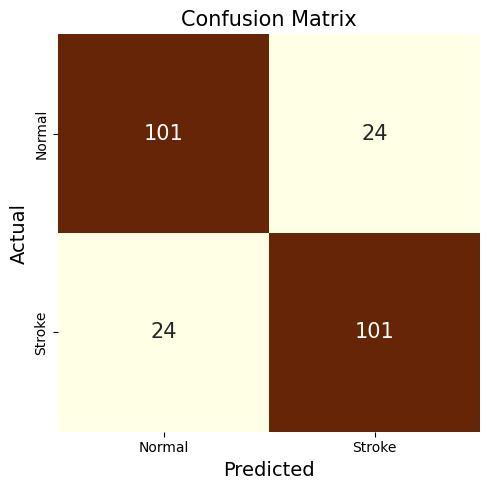

In [45]:
plt.figure(figsize=(5, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="YlOrBr",
    cbar=False,
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"],
    annot_kws={"size": 15}
)

plt.ylabel(
    "Actual",
    fontsize=14
)

plt.xlabel(
    "Predicted",
    fontsize=14
)

plt.title(
    "Confusion Matrix",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "../models/confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

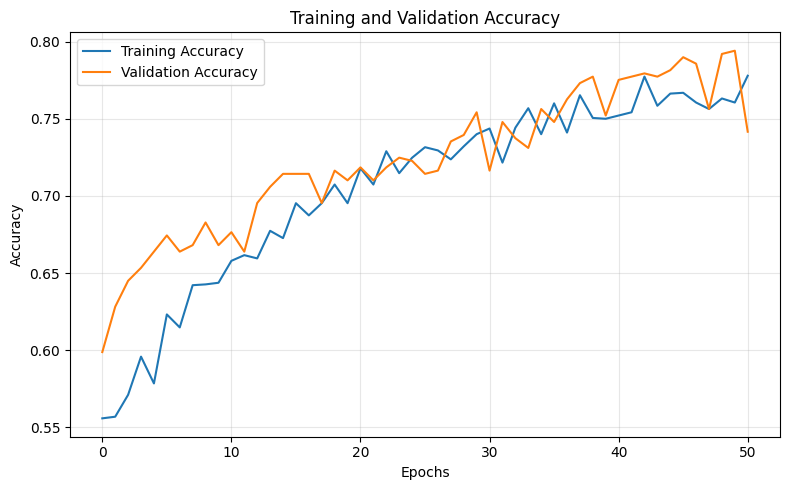

In [ ]:


plt.figure(figsize=(8, 5))

plt.plot(

    range(len(history["train_accuracy"])),
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    range(len(history["val_accuracy"])),
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel(
    "Epochs"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../models/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

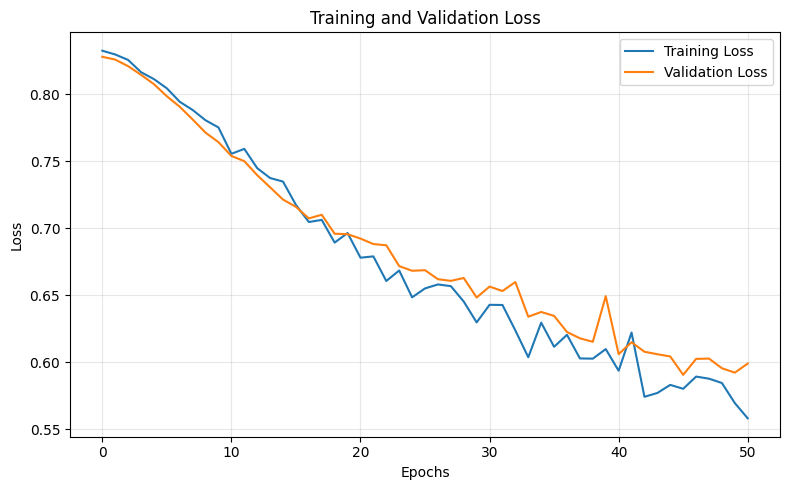

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(len(history['train_loss'])),
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    range(len(history['val_loss'])),
    history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel(
    "Epochs"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../models/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()